In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import mplniw.utils as ut
import cmocean
import niskine

In [2]:
root_dir = '/Users/zcasparcohen/codes/NIW/data/'
ds = xr.open_dataset(root_dir+'niskine_mooring_500m.nc')
grid = xr.open_dataset(root_dir+'niskine_mooring_grid_500m.nc')

topo = xr.open_dataset('/Users/zcasparcohen/Downloads/ETOPO_2022_v1_30s_N90W180_bed.nc').z.sel(lon=slice(-30,-15.3),lat=slice(55,64.8))
topo = topo.isel(lon=slice(0,None,1),lat=slice(0,None,1))

N2=xr.open_dataarray(root_dir+'roms_stratification.nc')
N2 = N2.where(N2>=0)

N2_niskine = xr.open_dataarray(root_dir+'N_daily.nc')

In [3]:
#Load moorings config
conf = niskine.io.load_config()
m1lon, m1lat, m1bottom_depth = niskine.io.mooring_location(mooring=1)
m2lon, m2lat, m2bottom_depth = niskine.io.mooring_location(mooring=2)
m3lon, m3lat, m3bottom_depth = niskine.io.mooring_location(mooring=3)

In [4]:
fc = ut.coriolis(grid.lat_rho)
H = -topo.sel(lat=grid.lat_rho.mean('xi_rho'),lon=grid.lon_rho.mean('eta_rho'),method='nearest')
H_niskine = -topo.sel(lat=slice(m2lat-0.2,m1lat+0.2),lon=slice(m3lon-0.2,m2lon+0.2))
g=9.81

In [5]:
H = H.rename({'eta_rho':'lat','xi_rho':'lon'})

/var/folders/vl/tj6snrv54zd212pkvk5g_l140000gn/T/ipykernel_1328/1670888842.py:1: UserWarning: rename 'eta_rho' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  H = H.rename({'eta_rho':'lat','xi_rho':'lon'})
/var/folders/vl/tj6snrv54zd212pkvk5g_l140000gn/T/ipykernel_1328/1670888842.py:1: UserWarning: rename 'xi_rho' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  H = H.rename({'eta_rho':'lat','xi_rho':'lon'})


In [6]:
N = np.sqrt(N2)

In [7]:
f = fc.mean('xi_rho').rename({'eta_rho':'lat'})

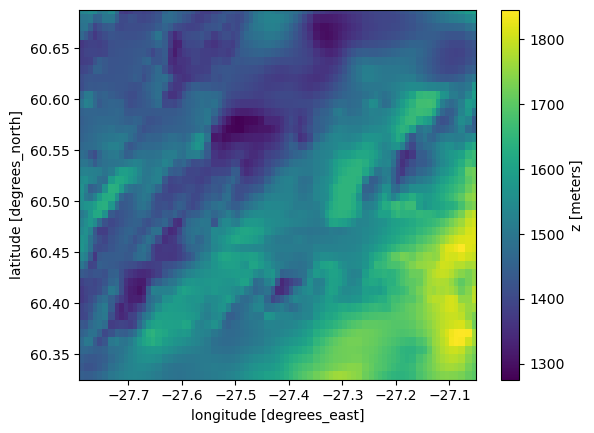

In [23]:
H.plot()

In [8]:
#Barotropic Rossby radius deformation scale
Lr = np.sqrt(g*H)/f
#Baroclinic Rossby radius deformation scale
n = 1
Lr_bc = N*H/(n*np.pi*f)

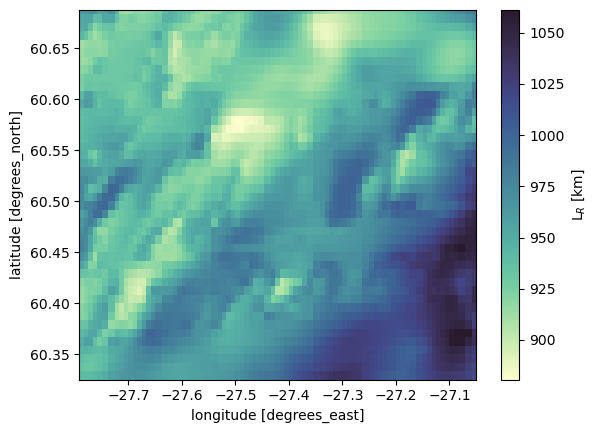

In [9]:
(Lr).plot(cmap=cmocean.cm.deep,cbar_kwargs={'label':r'L$_R$ [km]'})


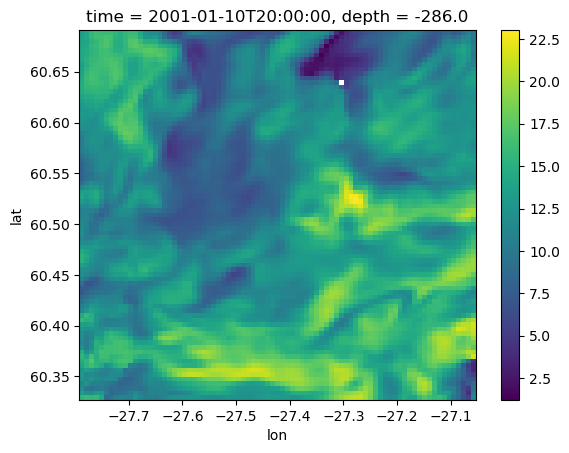

In [10]:
Lr_bc.isel(time=100,depth=30).plot()

In [25]:
def s2cpd(f):
    return 24*3600*f/2/np.pi

In [9]:
# Horizontal IW wavelength
lambda_v = 100
#np.arange(100,1000,500)
omega = xr.concat([1.01*f,f+(0.1/3600/24*2*np.pi),f+(0.2/3600/24*2*np.pi)],dim='omega')
#np.array([s2cpd(f)+0.1,s2cpd(f)+0.2])
#omega = 2*np.pi*omega/3600/24
#omega = np.insert(omega,0,1.01*f,axis=0)
#

In [10]:
lambda_h = lambda_v*N/np.sqrt(omega**2-f**2)

In [11]:
lambda_h = lambda_h.assign_coords({'omega':[om.mean() for om in omega]})

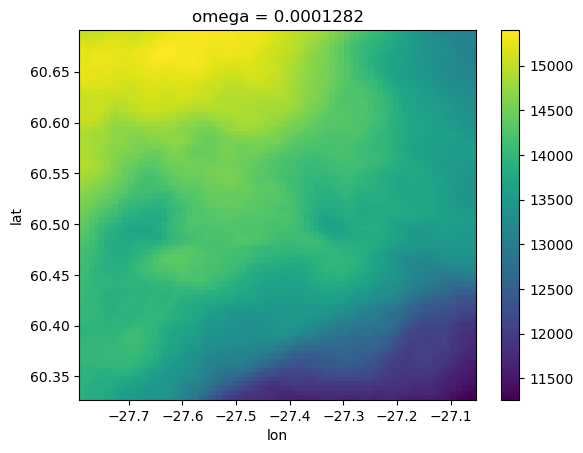

In [12]:
lambda_h.isel(omega=0).mean(['time','depth']).plot()

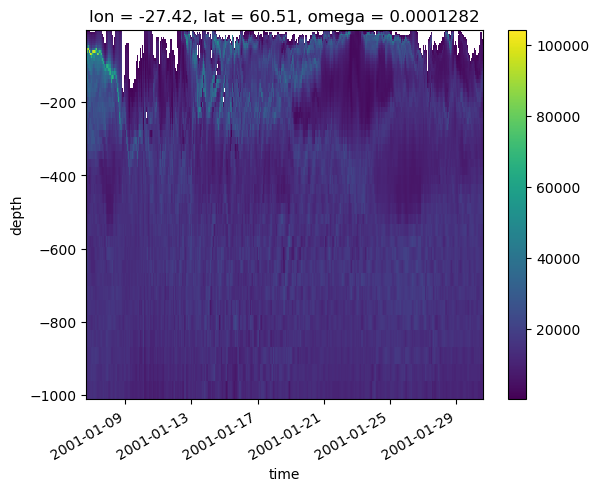

In [13]:
lambda_h.sel(lat=N.lat.median(),lon=N.lon.median(),omega=lambda_h.omega[0],method='nearest').plot(x='time')

In [14]:
Lr_bc = xr.concat([N*H/(n*np.pi*f) for n in np.arange(1,4)],dim='mode').assign_coords({'mode':np.arange(1,4)})

In [15]:
xr.Dataset({'l_IW':lambda_h,'Lr_bc':Lr_bc,'Lr':Lr}).to_netcdf(root_dir+'roms_scales.nc')

In [16]:
#Niskine
f_M1 = ut.coriolis(m1lat)
# Horizontal IW wavelength
lambda_v = 100
#np.arange(100,1000,500)
omega = np.array([1.01*f_M1,f_M1+(0.1/3600/24*2*np.pi),f_M1+(0.2/3600/24*2*np.pi)])

In [20]:
N_niskine=np.sqrt(N2_niskine)

In [23]:
#lambda_h = xr.concat([lambda_v*N_niskine/np.sqrt(om**2-f_M1**2) for om in omega],dim='omega')
lambda_h = lambda_h.assign_coords({'omega':[om.mean() for om in omega]})

/var/folders/vl/tj6snrv54zd212pkvk5g_l140000gn/T/ipykernel_1328/3385682084.py:2: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in fig.axes[0]:


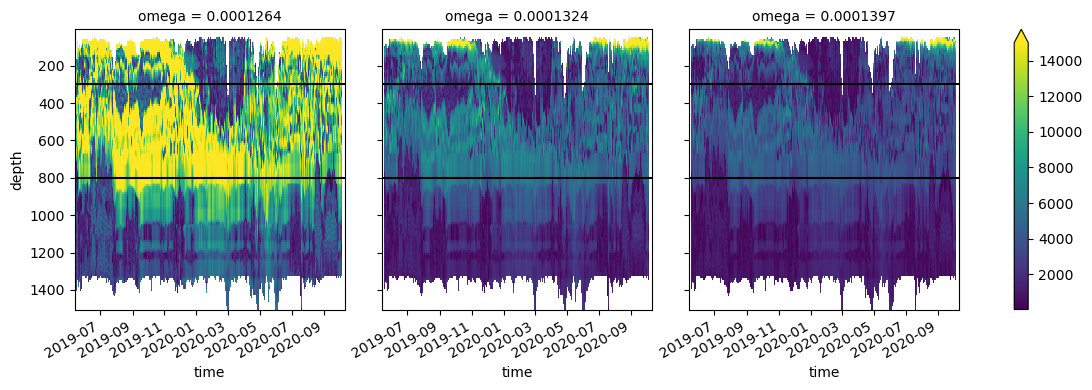

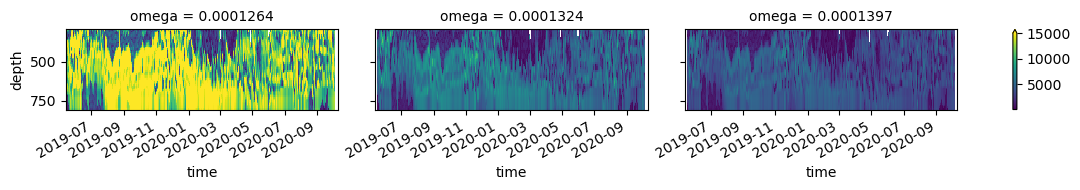

In [53]:

fig=lambda_h.plot(col='omega',yincrease=False,vmax=15000,figsize=(12,4))
for ax in fig.axes[0]:
    ax.axhline(300,c='k');ax.axhline(800,c='k')
    
fig=lambda_h.sel(depth=slice(300,800)).plot(col='omega',yincrease=False,vmax=15000,figsize=(12,2))

Text(0.5, 0, '$\\omega$ [s$^{-1}$]')

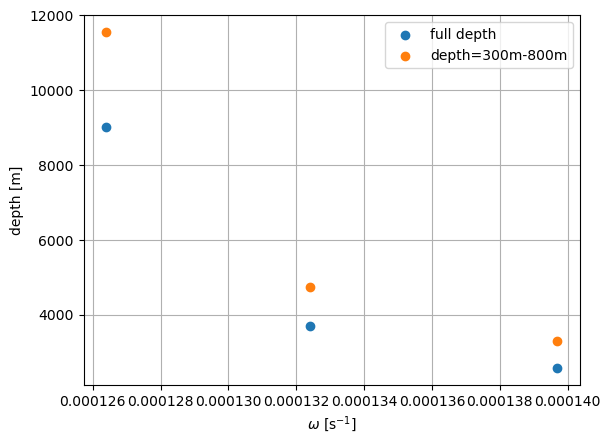

In [38]:
plt.scatter(lambda_h.omega,lambda_h.mean(['time','depth']),label='full depth')
plt.scatter(lambda_h.omega,lambda_h.sel(depth=slice(300,800)).mean(['time','depth']),label='depth=300m-800m')
plt.legend();plt.grid();plt.ylabel('depth [m]');plt.xlabel(r'$\omega$ [s$^{-1}$]')